# 01. EDA - About this notebook
This notebook explores the merged dataset to understand patterns in demand, prices, and carbon intensity. And derive scenario probability in decision-tree <br>
**Sections:**
1. Demand Patterns
2. Price Patterns
3. Carbon Intensity Patterns
4. EDA Summary

In [135]:
#SET UP 
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from entsoe import EntsoePandasClient

ROOT_DIR = Path(__file__).parent.parent if '__file__' in dir() else Path().resolve().parent
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR       = ROOT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    'figure.dpi':       120,
    'figure.facecolor': 'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
})
COLORS = {
    'demand':   '#065A82',
    'spot':     '#B45309',
    'balancing':'#B91C1C',
    'carbon':   '#2C5F2D',
    'light':    '#73C5C7',
    'medium':   '#0A9396',
    'peak':     '#005F73',
}

In [136]:
#Load Data & Convert gCO2 to kgCO2
df = pd.read_csv(PROCESSED_DIR / 'dataset.csv', index_col = 0)
df['ci_kgco2_mwh'] = df['ci_gco2_mwh']/1e3
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# 1. Demand

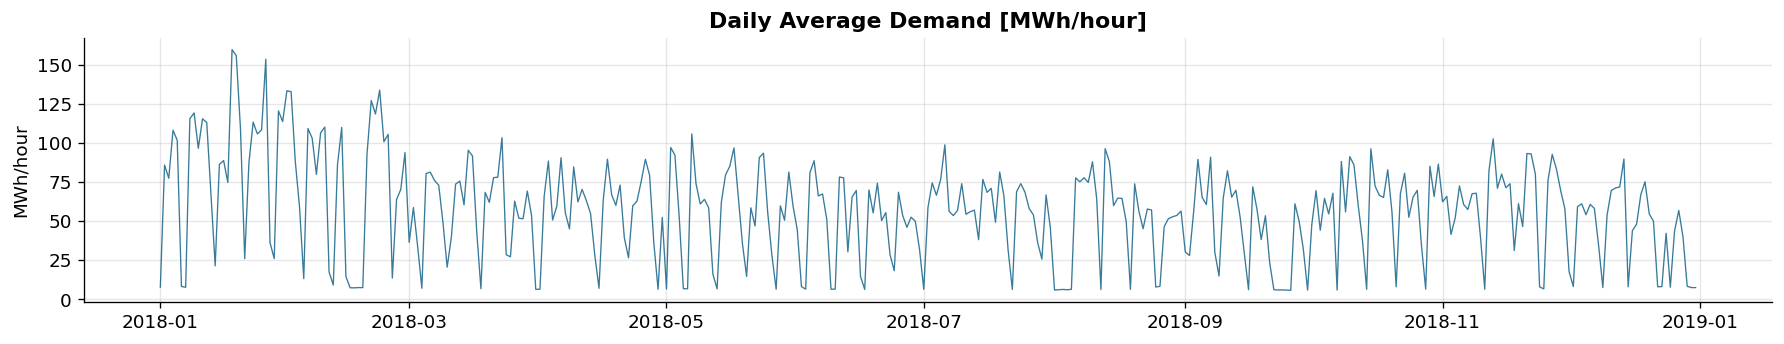

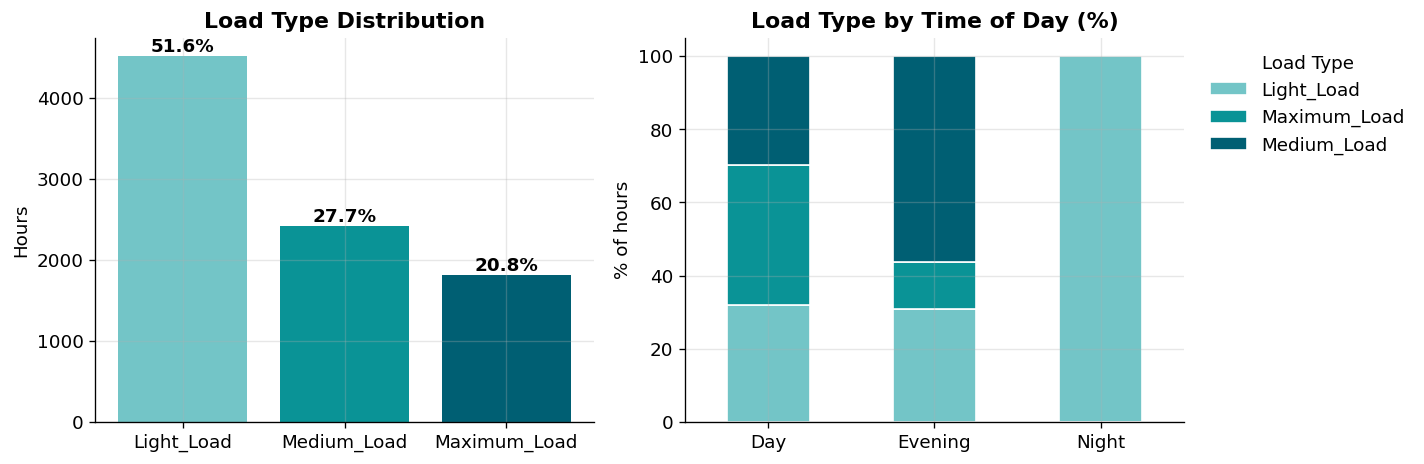


Load type empirical probabilities (for decision tree):
load_type
Light_Load      51.6
Medium_Load     27.7
Maximum_Load    20.8
Name: probability %, dtype: float64


In [138]:
#1.1. OVERVIEW & LOAD TYPE DISTRIBUTION

fig, axes = plt.subplots(figsize=(15, 3))

# Daily average
daily = df['demand_mwh'].resample('D').mean()
axes.plot(daily.index, daily.values, color=COLORS['demand'], linewidth=0.8, alpha=0.8)
axes.set_title('Daily Average Demand [MWh/hour]',fontweight='bold')
axes.set_ylabel('MWh/hour')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_demand_overview.png', bbox_inches='tight')
plt.show()

#LOAD TYPE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
load_counts = df['load_type'].value_counts()
load_pct    = (load_counts / len(df) * 100).round(1)
bars = axes[0].bar(load_counts.index, load_counts.values,
                    color=[COLORS['light'], COLORS['medium'], COLORS['peak']])
for bar, pct in zip(bars, load_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{pct}%', ha='center', fontweight='bold')
axes[0].set_title('Load Type Distribution', fontweight='bold')
axes[0].set_ylabel('Hours')

# Load type by time of day
pivot = df.groupby(['time_of_day', 'load_type']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', ax=axes[1], stacked=True,
               color=[COLORS['light'], COLORS['medium'], COLORS['peak']],
               edgecolor='white')
axes[1].set_title('Load Type by Time of Day (%)', fontweight='bold')
axes[1].set_ylabel('% of hours')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Load Type', frameon= False,bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig(FIG_DIR / '02_load_type.png', bbox_inches='tight')
plt.show()

print('\nLoad type empirical probabilities (for decision tree):')
print(load_pct.rename('probability %'))

# 2. Price

## 2.1. Day-ahead price

Price tier thresholds (for probs - decision tree):
  Cheap    < 41.15 €/MWh  (33.0% of hours)
  Normal   41.15 – 50.43 €/MWh  (34.0% of hours)
  Expensive > 50.43 €/MWh  (33.0% of hours)


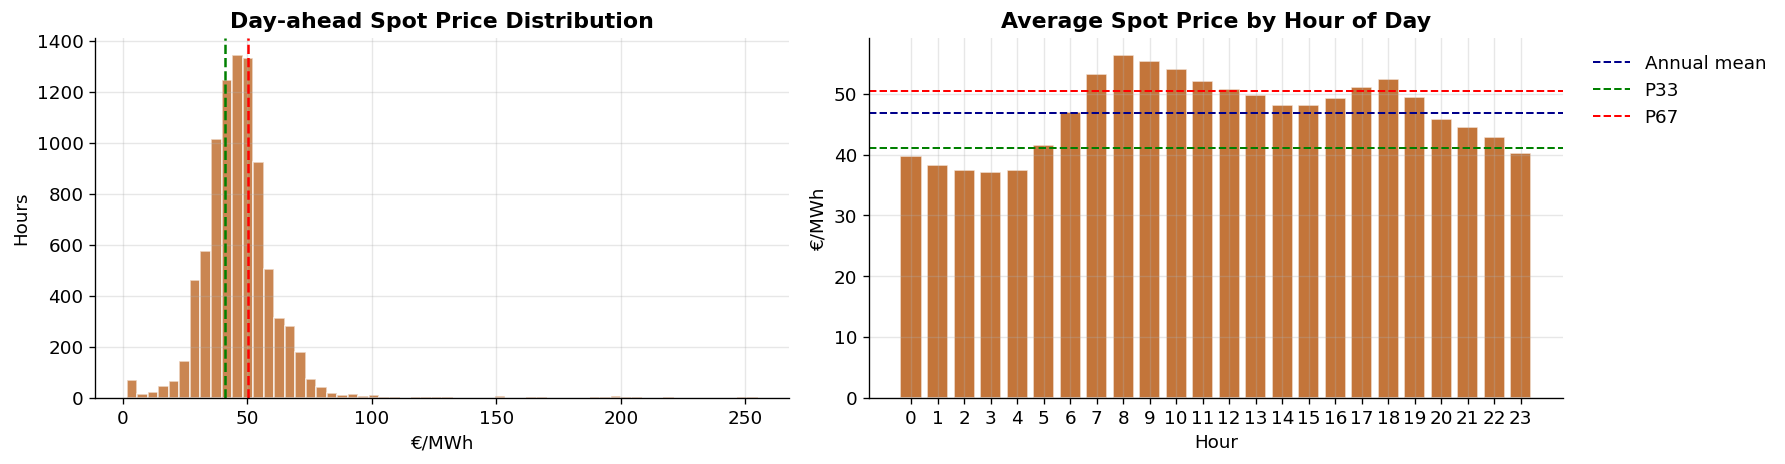

In [139]:
p33 = df['dayahead_price'].quantile(0.33)
p67 = df['dayahead_price'].quantile(0.67)
print(f'Price tier thresholds (for probs - decision tree):')
print(f'  Cheap    < {p33:.2f} €/MWh  ({(df["dayahead_price"] < p33).mean()*100:.1f}% of hours)')
print(f'  Normal   {p33:.2f} – {p67:.2f} €/MWh  ({((df["dayahead_price"] >= p33) & (df["dayahead_price"] < p67)).mean()*100:.1f}% of hours)')
print(f'  Expensive > {p67:.2f} €/MWh  ({(df["dayahead_price"] >= p67).mean()*100:.1f}% of hours)')

df['price_tier'] = pd.cut(
    df['dayahead_price'],
    bins=[-np.inf, p33, p67, np.inf],
    labels=['Cheap', 'Normal', 'Expensive']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Histogram by tier
axes[0].hist(df['dayahead_price'], bins=60, color=COLORS['spot'],
             alpha=0.7, edgecolor='white')
axes[0].axvline(p33, color='green',  linestyle='--', linewidth=1.5, label=f'P33 = {p33:.1f}')
axes[0].axvline(p67, color='red',    linestyle='--', linewidth=1.5, label=f'P67 = {p67:.1f}')
axes[0].set_title('Day-ahead Spot Price Distribution', fontweight='bold')
axes[0].set_xlabel('€/MWh')
axes[0].set_ylabel('Hours')

# Average spot price by hour of day
hourly_price = df.groupby('hour')['dayahead_price'].mean()
axes[1].bar(hourly_price.index, hourly_price.values,
             color=COLORS['spot'], alpha=0.8, edgecolor='white')
axes[1].axhline(df['dayahead_price'].mean(), color='darkblue',
                linestyle='--', linewidth=1.2, label='Annual mean')
axes[1].axhline(p33, color='green',
                linestyle='--', linewidth=1.2, label='P33')
axes[1].axhline(p67, color='red',
                linestyle='--', linewidth=1.2, label='P67')
axes[1].set_title('Average Spot Price by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('€/MWh')
axes[1].set_xticks(range(0, 24))
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig(FIG_DIR / '03_price_distribution.png', bbox_inches='tight')
plt.show()

## 2.2. Balancing Price vs Day-ahead Price

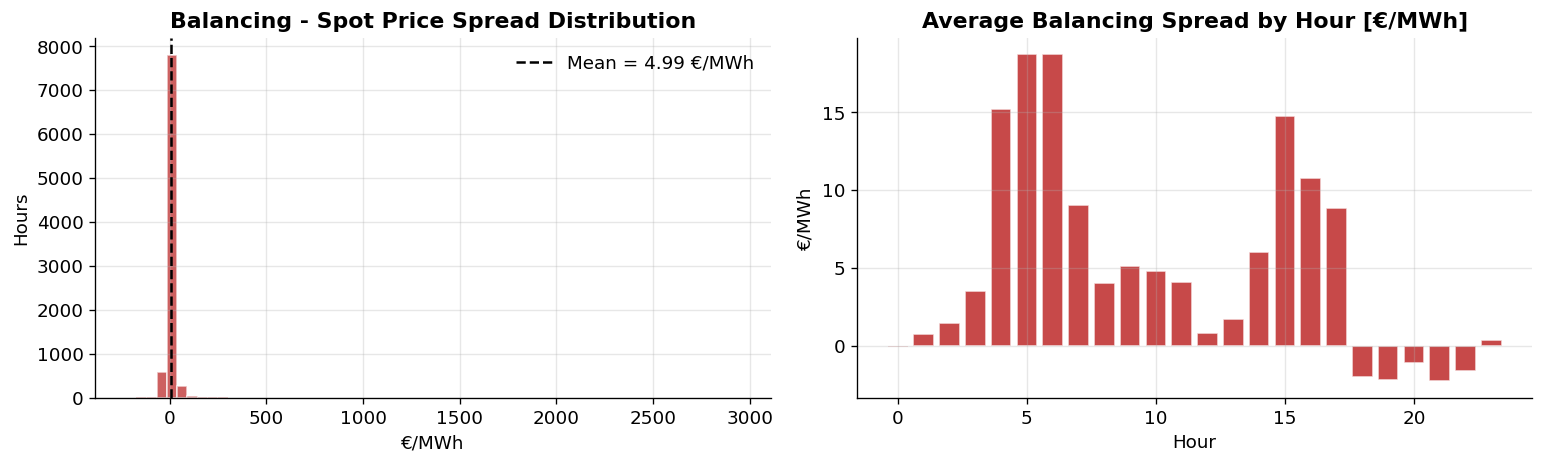

Balancing spread stats [€/MWh]:
count    8760.00
mean        4.99
std        44.02
min      -225.74
25%        -2.51
50%         0.78
75%         6.81
max      2950.95
Name: balancing_spread, dtype: float64

Avg spread as % of spot: 22.0%
Balancing spread is consistent -> Supply risk is real but modest vs cost %


In [144]:
df['balancing_spread']     = df['balancing_price'] - df['dayahead_price']
df['balancing_spread_pct'] = df['balancing_spread'] / df['dayahead_price'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Spread distribution
axes[0].hist(df['balancing_spread'], bins=60,
             color=COLORS['balancing'], alpha=0.7, edgecolor='white')
axes[0].axvline(df['balancing_spread'].mean(), color='black',
                linestyle='--', linewidth=1.5,
                label=f'Mean = {df["balancing_spread"].mean():.2f} €/MWh')
axes[0].set_title('Balancing - Spot Price Spread Distribution', fontweight='bold')
axes[0].set_xlabel('€/MWh')
axes[0].set_ylabel('Hours')
axes[0].legend(frameon=False)

# Hourly spread
hourly_spread = df.groupby('hour')['balancing_spread'].mean()
axes[1].bar(hourly_spread.index, hourly_spread.values,
             color=COLORS['balancing'], alpha=0.8, edgecolor='white')
axes[1].set_title('Average Balancing Spread by Hour [€/MWh]', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('€/MWh')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_balancing_spread.png', bbox_inches='tight')
plt.show()

print(f'Balancing spread stats [€/MWh]:')
print(df['balancing_spread'].describe().round(2))
print(f'\nAvg spread as % of spot: {df["balancing_spread_pct"].mean():.1f}%')
print(f'Balancing spread is consistent -> Supply risk is real but modest vs cost %')

## 2.3. Spot price vs Demand Profile

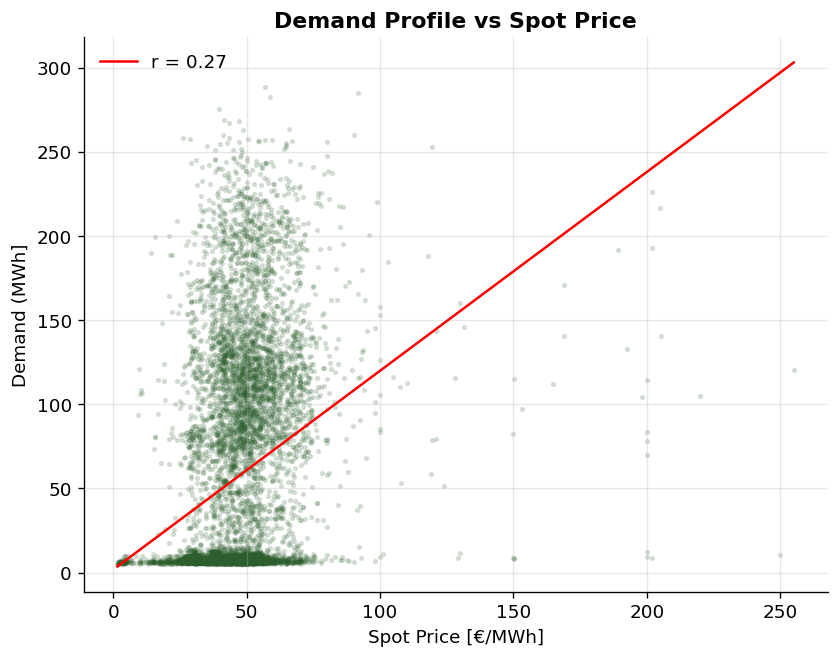

This suggests small but actually positive relationship. It is necessary to derive joint probability of price state & demand profile rather than assuming independent.


In [187]:
from scipy import stats
fig,axes = plt.subplots(figsize=(8,6))
axes.scatter(df['dayahead_price'], df['demand_mwh'],
                alpha=0.15, s=5, color=COLORS['carbon'])
# Add regression line
slope, intercept, r, p, _ = stats.linregress(
    df['dayahead_price'].dropna(),
    df['demand_mwh'].dropna()
)
x_line = np.linspace(df['dayahead_price'].min(), df['dayahead_price'].max(), 100)
axes.plot(x_line, slope * x_line + intercept,
             color='red', linewidth=1.5, label=f'r = {r:.2f}')
axes.set_title('Demand Profile vs Spot Price', fontweight='bold')
axes.set_xlabel('Spot Price [€/MWh]')
axes.set_ylabel('Demand (MWh]')
axes.legend(frameon=False)
plt.tight_layout
plt.savefig(FIG_DIR / '05_demand_profile_vs_spot_price.png')
plt.show()
print(f'This suggests small but actually positive relationship. It is necessary to derive joint probability of price state & demand profile rather than assuming independent.')

In [190]:
joint_table = pd.crosstab(
    df['load_type'], 
    df['price_tier'], 
    normalize='all'  
)
print('Joint Probabilities P(Load Type, Price Tier):')
print(joint_table.round(4))

print('\nSum check:', joint_table.sum().sum())  # should be 1.0

Joint Probabilities P(Load Type, Price Tier):
price_tier     Cheap  Normal  Expensive
load_type                              
Light_Load    0.2261  0.1834     0.1062
Maximum_Load  0.0447  0.0622     0.1006
Medium_Load   0.0592  0.0944     0.1231

Sum check: 0.9999999999999998


# 3. CO2 Intensity 

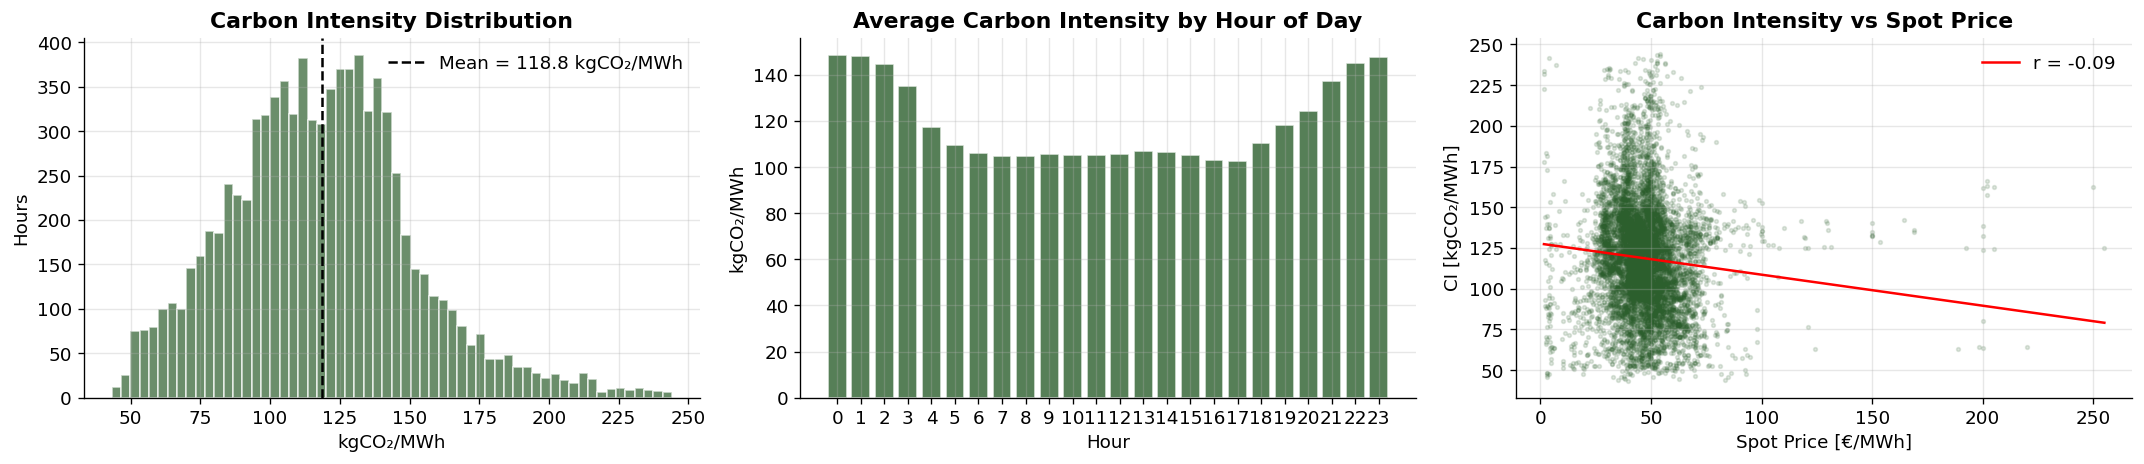

CI stats [kgCO₂/MWh]:
count    8760.00
mean      118.76
std        33.44
min        43.16
25%        95.81
50%       117.93
75%       138.47
max       244.15
Name: ci_kgco2_mwh, dtype: float64


In [186]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Distribution
axes[0].hist(df['ci_kgco2_mwh'], bins=60,
             color=COLORS['carbon'], alpha=0.7, edgecolor='white')
axes[0].axvline(df['ci_kgco2_mwh'].mean(), color='black',
                linestyle='--', linewidth=1.5,
                label=f'Mean = {df["ci_kgco2_mwh"].mean():.1f} kgCO₂/MWh')
axes[0].set_title('Carbon Intensity Distribution', fontweight='bold')
axes[0].set_xlabel('kgCO₂/MWh')
axes[0].set_ylabel('Hours')
axes[0].legend(frameon=False)

# Hourly profile
hourly_ci = df.groupby('hour')['ci_kgco2_mwh'].mean()
axes[1].bar(hourly_ci.index, hourly_ci.values,
             color=COLORS['carbon'], alpha=0.8, edgecolor='white')
axes[1].set_title('Average Carbon Intensity by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('kgCO₂/MWh')
axes[1].set_xticks(range(0, 24))

# CO2 vs Spot Price correlation
from scipy import stats
# Scatter
axes[2].scatter(df['dayahead_price'], df['ci_kgco2_mwh'],
                alpha=0.15, s=5, color=COLORS['carbon'])
# Add regression line
slope, intercept, r, p, _ = stats.linregress(
    df['dayahead_price'].dropna(),
    df['ci_kgco2_mwh'].dropna()
)
x_line = np.linspace(df['dayahead_price'].min(), df['dayahead_price'].max(), 100)
axes[2].plot(x_line, slope * x_line + intercept,
             color='red', linewidth=1.5, label=f'r = {r:.2f}')
axes[2].set_title('Carbon Intensity vs Spot Price', fontweight='bold')
axes[2].set_xlabel('Spot Price [€/MWh]')
axes[2].set_ylabel('CI [kgCO₂/MWh]')
axes[2].legend(frameon=False)


plt.tight_layout()
plt.savefig(FIG_DIR / '06_carbon_intensity.png', bbox_inches='tight')
plt.show()

print(f'CI stats [kgCO₂/MWh]:')
print(df['ci_kgco2_mwh'].describe().round(2))

In [191]:
print(f'CO2 intensity by hour has opposite trend vs Spot price, highlighting trade-off between chasing cheap price or lower carbon intensity.')
print(f'Practically zero relationship between spot price & CO2 intensity. Cost minimization and carbon minimization are largely independent objectives.')
print(f'Firm can\'t "accidentally" reduce carbon by chasing cheap spot prices')

CO2 intensity by hour has opposite trend vs Spot price, highlighting trade-off between chasing cheap price or lower carbon intensity.
Practically zero relationship between spot price & CO2 intensity. Cost minimization and carbon minimization are largely independent objectives.
Firm can't "accidentally" reduce carbon by chasing cheap spot prices


# 4. EDA Summary

## Key Findings

| Finding | Implication for Model |
|---|---|
| Balancing spread averages 22% of spot price, consistently positive in distribution | Supply risk is real but modest relative to total cost —> `e · (x₁+x₂) · max(0, p_bal(t) − p₃(t))`  is a meaningful but secondary term |
| Demand (Load Type) and Spot Price show a small but real positive relationship (r=0.27) | Independence assumption rejected ->  joint probability table P(Load Type, Price Tier) computed empirically for the 9 decision tree leaf nodes |
| Joint probabilities show Light Load skews toward Cheap (0.226 vs 0.172 if independent), Maximum Load skews toward Expensive (0.101 vs 0.068 if independent) | Decision tree leaf node probabilities read directly from data -> **output #01** (Scenario Probability Table) |
| Carbon intensity averages 118.8 kgCO₂/MWh with meaningful variation (std=33.4, range 43–244) | CI varies enough hour-to-hour that green sourcing decisions have real impact |
| Carbon intensity follows the **opposite** hourly pattern to spot price (high CI at night, low CI during day vs low price at night, high price during day) | Genuine trade-off exists: cheap-but-dirty hours vs expensive-but-cleaner hours |
| Carbon intensity vs spot price correlation is negligible (r=-0.09) | Cost minimization and carbon minimization are independent objectives -> w₃ represents a genuinely separate priority |

## Output #1

**Joint Probability Table - Pr(Load Type, Price Tier)**

Empirical joint distribution forms the basis for the 9-scenario decision tree. <br>
Light Load skews toward Cheap prices (0.226 vs 0.172 if independent); Maximum Load skews toward Expensive prices (0.101 vs 0.068 if independent). <br>

| Load Type | Cheap | Normal | Expensive | Row Total |
|---|---|---|---|---|
| Light Load | 0.2261 | 0.1834 | 0.1062 | 0.5157 |
| Medium Load | 0.0592 | 0.0944 | 0.1231 | 0.2767 |
| Maximum Load | 0.0447 | 0.0622 | 0.1006 | 0.2075 |
| **Column Total** | **0.3300** | **0.3400** | **0.3299** | **1.0000** |

**Next notebook:** `02_decision_tree.ipynb` - build the 9-scenario probability table from the joint distribution above